In [ ]:
# PART A: DATASET PREPARATION
# RNN TEXT GENERATION - TINY SHAKESPEARE
# Name    : Ramya R
# Roll No : 24BAD096

# Import required libraries
import numpy as np
import tensorflow as tf
import requests

# 1. LOAD TINY SHAKESPEARE DATASET

url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
response = requests.get(url)
if response.status_code == 200:
    text = response.text
    print("Tiny Shakespeare dataset loaded successfully!")
else:
    raise Exception("Failed to download dataset.")

# 2. EXPLORE DATASET
print("\nTotal Characters:", len(text))
print("\nSample Text:")
print(text[:1000])

# 3. CONVERT TEXT TO LOWERCASE
text = text.lower()
print("\nLowercase Text Sample:")
print(text[:500])

# 4. TOKENIZE TEXT INTO INDIVIDUAL WORDS
words = text.split()
print("\nTotal Number of Words:", len(words))

print("\nFirst 20 Tokens:")
print(words[:20])

# 5. BUILD VOCABULARY
vocab = sorted(set(words))
word_to_index = {
    word: index + 1
    for index, word in enumerate(vocab)
}
index_to_word = {
    index: word
    for word, index in word_to_index.items()
}
vocab_size = len(word_to_index) + 1
print("\nVocabulary Size:", vocab_size)
print("\nSample Vocabulary:")
for word in list(word_to_index.keys())[:10]:
    print(word, ":", word_to_index[word])

# 6. CONVERT WORDS TO NUMERICAL REPRESENTATIONS
encoded_words = [
    word_to_index[word]
    for word in words
]

print("\nFirst 20 Words:")
print(words[:20])

print("\nFirst 20 Numerical Values:")
print(encoded_words[:20])

# 7. GENERATE INPUT SEQUENCES
SEQUENCE_LENGTH = 20

sequences = []
targets = []

for i in range(1, len(encoded_words)):

    start = max(0, i - SEQUENCE_LENGTH)

    sequence = encoded_words[start:i]

    target = encoded_words[i]

    sequences.append(sequence)
    targets.append(target)

print("\nTotal Sequences:", len(sequences))

# 8. APPLY PADDING
X = tf.keras.utils.pad_sequences(
    sequences,
    maxlen=SEQUENCE_LENGTH,
    padding="pre",
    truncating="pre"
)

y = np.array(targets)

print("\nAfter Padding:")
print("Input Shape :", X.shape)
print("Target Shape:", y.shape)


# 9. TRAINING AND VALIDATION SPLIT
split_index = int(0.80 * len(X))

X_train = X[:split_index]
y_train = y[:split_index]

X_val = X[split_index:]
y_val = y[split_index:]

print("\n==============================")
print("DATASET SPLIT")
print("==============================")

print("Training Input Shape   :", X_train.shape)
print("Training Target Shape  :", y_train.shape)

print("Validation Input Shape :", X_val.shape)
print("Validation Target Shape:", y_val.shape)

print("\nTraining Samples   :", len(X_train))
print("Validation Samples :", len(X_val))

print("\nDATASET PREPARATION COMPLETED")

Tiny Shakespeare dataset loaded successfully!

Total Characters: 1115394

Sample Text:
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor citizens, the patricians good.
What authority surfeits on would relieve us: if they
would yield us but the superfluity, while it were
wholesome, we might guess they relieved us humanely;
but they think we are too dear: the leanness that
afflicts us, the object of our misery, is as an
inventory to particularise their abundance; our
sufferance is a gain to them Let us revenge this with
our pikes, ere we become 

In [ ]:
# PART B: IMPLEMENTING THE RNN MODEL
# RNN TEXT GENERATION - TINY SHAKESPEARE
# Name    : Ramya R
# Roll No : 24BAD096

# Import TensorFlow
import tensorflow as tf

# Model parameters
EMBEDDING_DIM = 128
RNN_UNITS = 128

# Create RNN model
model = tf.keras.Sequential([

    # Embedding layer converts word indices into vectors
    tf.keras.layers.Embedding(
        input_dim=vocab_size,
        output_dim=EMBEDDING_DIM
    ),

    # Simple RNN layer learns sequential patterns
    tf.keras.layers.SimpleRNN(
        RNN_UNITS
    ),

    # Dense layer predicts the next word
    tf.keras.layers.Dense(
        vocab_size,
        activation="softmax"
    )
])

# Compile the model
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Display student details
print("Student Name : Ramya R")
print("Roll No      : 24BAD096")

# Display model architecture
print("\nRNN MODEL ARCHITECTURE")

# Display model summary
model.summary()

# Display completion message
print("\nPART B: RNN MODEL IMPLEMENTATION COMPLETED")

Student Name : Ramya R
Roll No      : 24BAD096

RNN MODEL ARCHITECTURE


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


PART B: RNN MODEL IMPLEMENTATION COMPLETED


Name    : Ramya R
Roll No : 24BAD096

RNN MODEL TRAINING
Epoch 1/2
1267/1267 ━━━━━━━━━━━━━━━━━━━━ 281s 220ms/step - accuracy: 0.0372 - loss: 7.5562 - val_accuracy: 0.0409 - val_loss: 7.6071
Epoch 2/2
1267/1267 ━━━━━━━━━━━━━━━━━━━━ 274s 216ms/step - accuracy: 0.0698 - loss: 6.7678 - val_accuracy: 0.0668 - val_loss: 7.4596

MODEL PERFORMANCE
Training Accuracy   : 8.96 %
Validation Accuracy : 6.68 %
Training Loss       : 6.245
Validation Loss     : 7.4596


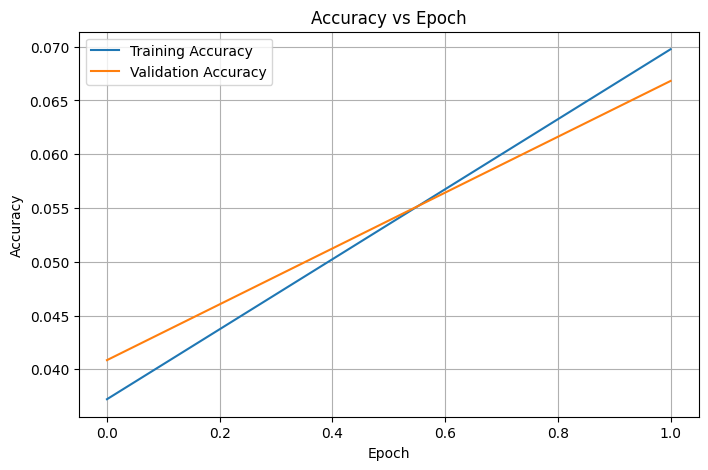

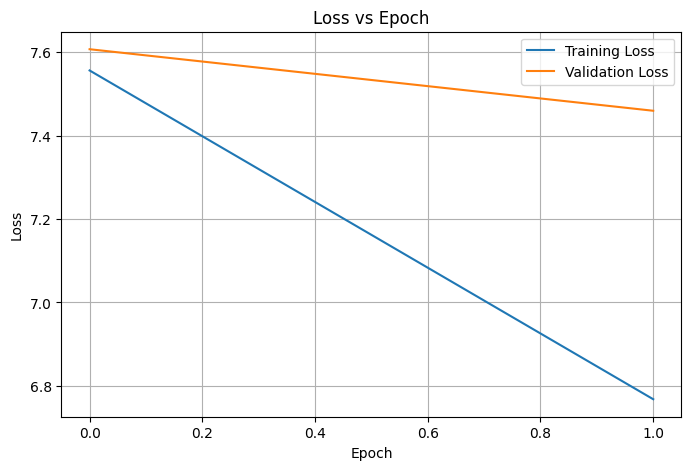


PART C: TRAINING AND EVALUATION COMPLETED


In [ ]:
# PART C: TRAINING AND EVALUATION
# RNN TEXT GENERATION - TINY SHAKESPEARE
# Name    : Ramya R
# Roll No : 24BAD096

# Import matplotlib for plotting graphs
import matplotlib.pyplot as plt

# Training parameters
EPOCHS = 2
BATCH_SIZE = 128

# Display student details
print("Name    : Ramya R")
print("Roll No : 24BAD096")

# Display training message
print("\nRNN MODEL TRAINING")

# Train the RNN model
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)

# Evaluate the model on training data
train_loss, train_accuracy = model.evaluate(
    X_train,
    y_train,
    verbose=0
)

# Evaluate the model on validation data
val_loss, val_accuracy = model.evaluate(
    X_val,
    y_val,
    verbose=0
)

# Display model performance
print("\nMODEL PERFORMANCE")

# Display training and validation accuracy
print("Training Accuracy   :", round(train_accuracy * 100, 2), "%")
print("Validation Accuracy :", round(val_accuracy * 100, 2), "%")

# Display training and validation loss
print("Training Loss       :", round(train_loss, 4))
print("Validation Loss     :", round(val_loss, 4))

# Create accuracy graph
plt.figure(figsize=(8, 5))

# Plot training accuracy
plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

# Plot validation accuracy
plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

# Add graph labels and title
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epoch")
plt.legend()
plt.grid(True)
plt.show()

# Create loss graph
plt.figure(figsize=(8, 5))

# Plot training loss
plt.plot(
    history.history["loss"],
    label="Training Loss"
)

# Plot validation loss
plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

# Add graph labels and title
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epoch")
plt.legend()
plt.grid(True)
plt.show()

# Display completion message
print("\nPART C: TRAINING AND EVALUATION COMPLETED")

In [ ]:
# PART D: TEXT GENERATION
# RNN TEXT GENERATION - TINY SHAKESPEARE
# TEXT GENERATION FUNCTION
def generate_text(seed_text, num_words=25):
    # Convert seed text to lowercase
    seed_words = seed_text.lower().split()
    # Keep only words available in vocabulary
    seed_words = [
        word for word in seed_words
        if word in word_to_index
    ]
    if len(seed_words) == 0:
        return "Seed words are not found in the vocabulary."
    # Generate words one by one
    for _ in range(num_words):
        # Convert words to numerical values
        encoded = [
            word_to_index[word]
            for word in seed_words
        ]
        # Keep only the last SEQUENCE_LENGTH words
        encoded = encoded[-SEQUENCE_LENGTH:]
        # Apply padding
        padded = tf.keras.utils.pad_sequences(
            [encoded],
            maxlen=SEQUENCE_LENGTH,
            padding="pre",
            truncating="pre"
        )
        # Predict next word
        prediction = model.predict(
            padded,
            verbose=0
        )
        # Get word with highest probability
        predicted_index = np.argmax(prediction[0])

        # Convert index back to word
        predicted_word = index_to_word.get(
            predicted_index,
            ""
        )
        if predicted_word == "":
            break

        # Add predicted word to the sequence
        seed_words.append(predicted_word)
    return " ".join(seed_words)

# GENERATE MULTIPLE TEXT SAMPLES
seeds = [
    "the king",
    "my lord",
    "love is",
    "to be",
    "when i"
]
print("GENERATED TEXT SAMPLES")
for seed in seeds:
    print("\nSeed Input:", seed)
    generated_text = generate_text(
        seed,
        num_words=25
    )
    print("Generated Text:")
    print(generated_text)
    print("-" * 60)
print("PART D: TEXT GENERATION COMPLETED")

GENERATED TEXT SAMPLES

Seed Input: the king
Generated Text:
the king reverend reverend halt. reverend station; reverend empty unvalued aristotle's scratches backward bell, tods; tips digress; unlike, alacrity finger, reared theirs. undone! gallop born. mean? seeds
------------------------------------------------------------

Seed Input: my lord
Generated Text:
my lord reverend reverend reverend 'banished'? imperial; station; reverend reverend world--why, want bawds. faces shrouds fire? 's. lived. belike. dish: me,-- gregory; behind-door-work: over-leather. highness starved ariel,
------------------------------------------------------------

Seed Input: love is
Generated Text:
love is associate reverend reverend reverend reverend reverend appeareth uncles sees, shoes. bended, withheld. judged o'erleap prank'd pursue create standest surrey chisel removed green-sickness paper church? reply.
------------------------------------------------------------

Seed Input: to be
Generated Text:
to